In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.models import Model
from tensorflow.keras.datasets import cifar10



In [12]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [13]:
# Create validation data from training data
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42
)


In [14]:

X_train.shape , y_train.shape , X_test.shape , y_test.shape, X_val.shape , y_val.shape

((40000, 32, 32, 3),
 (40000, 1),
 (10000, 32, 32, 3),
 (10000, 1),
 (10000, 32, 32, 3),
 (10000, 1))

array([[[34, 36, 43],
        [37, 37, 51],
        [44, 44, 64],
        ...,
        [62, 73, 93],
        [52, 63, 83],
        [45, 57, 77]],

       [[35, 35, 37],
        [34, 34, 40],
        [34, 33, 43],
        ...,
        [58, 69, 89],
        [50, 60, 80],
        [47, 58, 78]],

       [[34, 33, 35],
        [33, 32, 36],
        [33, 32, 38],
        ...,
        [66, 77, 97],
        [51, 62, 82],
        [53, 64, 84]],

       ...,

       [[32, 32, 38],
        [32, 31, 37],
        [33, 33, 38],
        ...,
        [41, 38, 45],
        [34, 31, 38],
        [36, 32, 40]],

       [[33, 31, 36],
        [32, 30, 36],
        [34, 32, 37],
        ...,
        [37, 35, 40],
        [32, 29, 35],
        [30, 28, 33]],

       [[37, 32, 35],
        [37, 32, 36],
        [37, 33, 36],
        ...,
        [49, 47, 49],
        [47, 45, 48],
        [58, 56, 58]]], dtype=uint8)
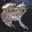

In [15]:
X_train[0]

array([[[185, 185, 178],
        [179, 176, 164],
        [188, 183, 166],
        ...,
        [131, 122, 107],
        [160, 152, 141],
        [202, 198, 193]],

       [[183, 184, 180],
        [182, 180, 171],
        [196, 192, 177],
        ...,
        [134, 124, 109],
        [159, 151, 140],
        [205, 200, 195]],

       [[183, 185, 184],
        [182, 181, 175],
        [198, 195, 184],
        ...,
        [130, 120, 105],
        [154, 146, 135],
        [204, 200, 195]],

       ...,

       [[108, 112, 114],
        [108, 112, 114],
        [103, 107, 109],
        ...,
        [104, 103, 111],
        [106, 105, 113],
        [104, 103, 111]],

       [[100, 103, 107],
        [101, 105, 109],
        [102, 106, 110],
        ...,
        [106, 105, 113],
        [106, 105, 113],
        [106, 105, 113]],

       [[ 96,  99, 105],
        [ 92,  95, 101],
        [ 92,  95, 101],
        ...,
        [106, 105, 112],
        [105, 104, 112],
        [106, 105, 113]]], dtype=uint8)
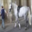

In [16]:
X_val[0]

In [17]:
y_train[0]

array([6], dtype=uint8)

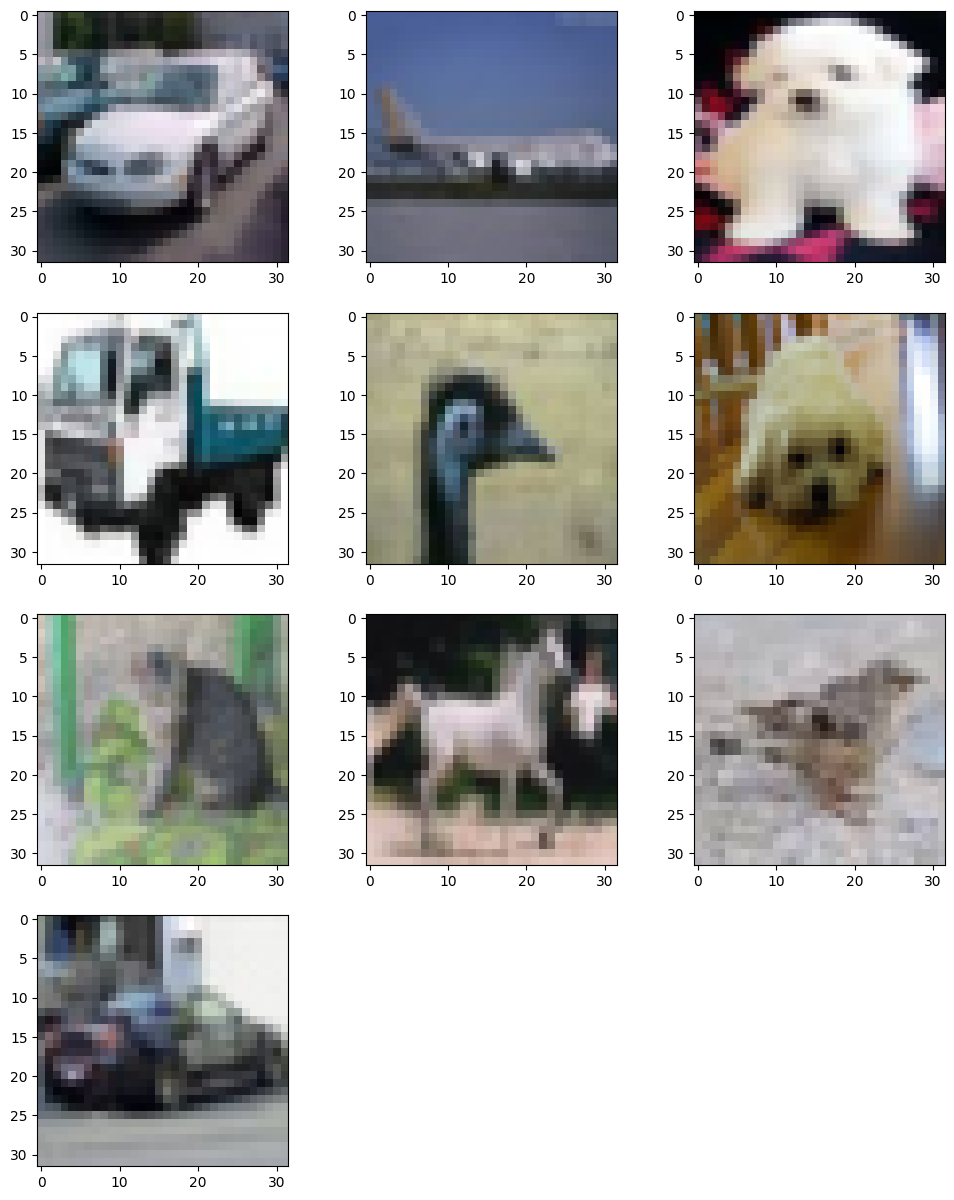

In [18]:
plt.figure(figsize=(12,15))
np.random.seed(0)
idx =np.random.randint(0,40000,10)
for i in range(len(idx)):
    plt.subplot(4,3,i+1)
    plt.imshow(X_train[idx[i]],cmap='gray')
plt.show()

In [19]:
# Data preprocessing

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_val = X_val.astype('float32')

In [20]:
# Normalization
X_train = X_train/255
X_test = X_test/255
X_val = X_val/255

In [21]:
print(X_train.min(), X_train.max())
print(X_val.min(), X_val.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0
0.0 1.0


In [22]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    AveragePooling2D,
    GlobalAveragePooling2D,
    Dropout,
    BatchNormalization
)

In [23]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

from tensorflow.keras.regularizers import l2


In [24]:
model = Sequential()
model.add(Conv2D(32,(3,3),  padding='same',activation='relu',kernel_regularizer=l2(0.0001),input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
#model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),  padding='same',activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
#model.add(MaxPooling2D((2,2)))
model.add(AveragePooling2D(pool_size=(2,2)))


model.add(Conv2D(128,(3,3),  padding='same',activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
#model.add(MaxPooling2D((2,2)))
model.add(AveragePooling2D(pool_size=(2,2)))




model.add(Conv2D(256,(3,3),  padding='same',activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
#model.add(MaxPooling2D((2,2)))
#model.add(AveragePooling2D(pool_size=(2,2)))




# Convert 2D,3d -> 1D
#model.add(Flatten())
model.add(GlobalAveragePooling2D())


# hideen leyer
model.add(Dense(100, activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(70, activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))



model.add(Dense(30, activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(15, activation='relu',kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(10, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:

from keras.optimizers import SGD, Adagrad, Adam, RMSprop,Adamax

adam = Adam(learning_rate=0.0005)

model.compile(
    optimizer=adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [27]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.2274 - loss: 2.2103 - val_accuracy: 0.3664 - val_loss: 1.7678 - learning_rate: 5.0000e-04
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.3391 - loss: 1.8360 - val_accuracy: 0.4211 - val_loss: 1.6169 - learning_rate: 5.0000e-04
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.4112 - loss: 1.6696 - val_accuracy: 0.4283 - val_loss: 1.6365 - learning_rate: 5.0000e-04
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4664 - loss: 1.5482 - val_accuracy: 0.4227 - val_loss: 1.8938 - learning_rate: 5.0000e-04
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5213 - loss: 1.4371 - val_accuracy: 0.5649 - val_loss: 1.3239 - learning_rate: 5.0000e-04
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5588 - loss: 1.3712 - val_accuracy: 0.6147 - val_loss: 1.1582 - learning_rate: 5.0000e-04
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 4

In [28]:
# Testing data evaluation

loss, accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", loss)

print("Testing Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8290 - loss: 0.6386
Testing Loss: 0.6385672688484192
Testing Accuracy: 0.8289999961853027


In [29]:
# Training data evaluation
train_loss, train_accuracy = model.evaluate(X_train, y_train)
print("Training Accuracy :", train_accuracy)
print("Training Loss : ", train_loss)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8988 - loss: 0.3991
Training Accuracy : 0.8988000154495239
Training Loss :  0.39911237359046936


In [43]:
predictions = model.predict(X_test)
predicted_class = np.argmax(predictions[0])
print(predicted_class)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
3


In [33]:
print("Actual:", y_test[0])
print("Predicted:", np.argmax(predictions[0]))

Actual: [3]
Predicted: 3


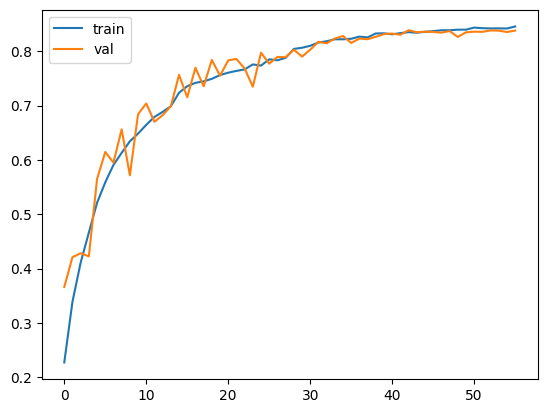

In [37]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])

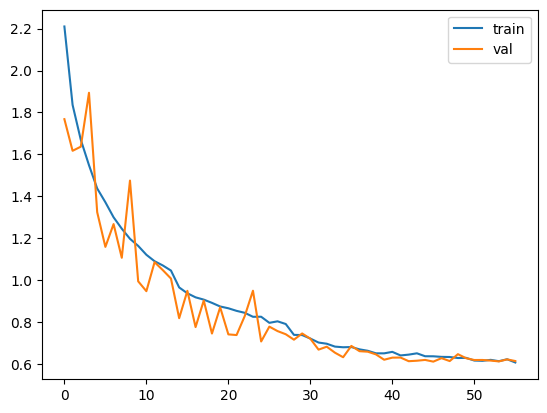

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])

In [44]:

# Predictions
y_pred = model.predict(X_test)

# Predicted classes
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test.flatten()

# Report
print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1000
           1       0.89      0.94      0.91      1000
           2       0.79      0.78      0.78      1000
           3       0.72      0.58      0.64      1000
           4       0.83      0.79      0.81      1000
           5       0.79      0.68      0.73      1000
           6       0.80      0.93      0.86      1000
           7       0.83      0.91      0.87      1000
           8       0.91      0.90      0.91      1000
           9       0.85      0.93      0.88      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



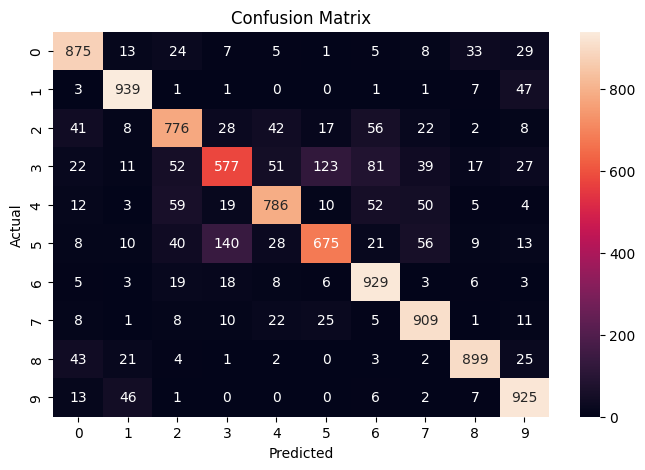

In [47]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np

In [49]:
# Convert labels to binary format
y_test_bin = label_binarize(y_true, classes=[0,1,2,3,4,5,6,7,8,9])

# Predict probabilities
y_pred_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


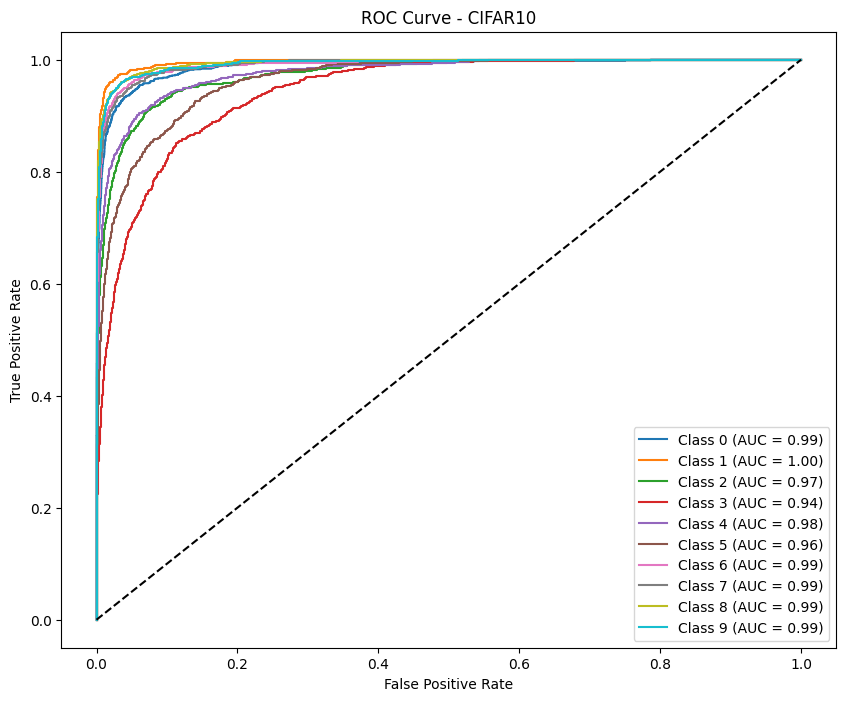

In [50]:
plt.figure(figsize=(10,8))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Random guess line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CIFAR10")

plt.legend()
plt.show()

In [52]:
model.save("cifar10_model.keras")